## GIAI ĐOẠN 2: XÂY DỰNG MÔ HÌNH DỰ ĐOÁN NĂNG LỰC HỌC SINH, ĐỘ KHÓ VÀ ĐỘ PHÂN LOẠI HỌC SINH QUA CÁC CÂU HỎI

In [11]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('data/train_cleaned.csv')
df_parts = pd.read_csv('data/train_merged_with_parts.csv')

print(f"Đã đọc thành công {len(df_train)} dòng dữ liệu!")
df_train.head()

Đã đọc thành công 4812958 dòng dữ liệu!


,row_id,timestamp,user_id,content_id,content_type_id,task_container_id,user_answer,answered_correctly,prior_question_elapsed_time,prior_question_had_explanation
0,0,0,115,5692,0,1,3,1,NaN,NaN
1,1,56943,115,5716,0,2,2,1,37000.0,False
2,2,118363,115,128,0,0,0,1,55000.0,False
3,3,131167,115,7860,0,3,0,1,19000.0,False
4,4,137965,115,7922,0,4,1,1,11000.0,False


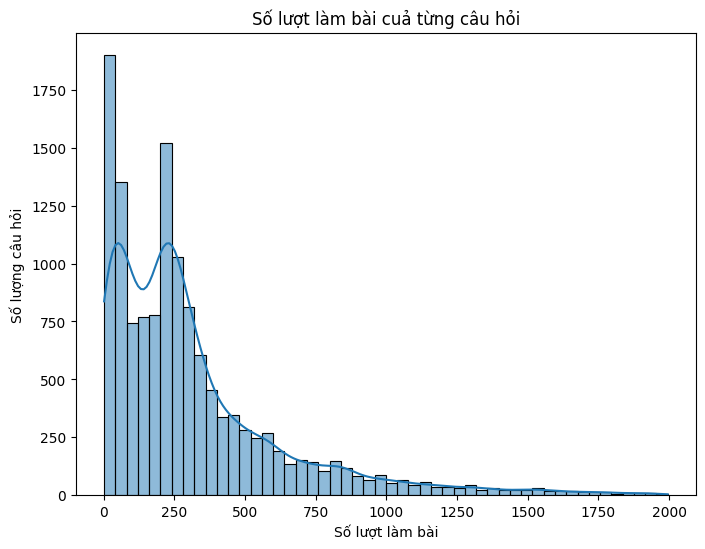

NHẬN XÉT:
- Tổng số câu hỏi trong kho: 13,484 câu.
- Trung vị 230.0 lượt làm bài.
- Lấy ngưỡng >= 66 lượt làm bài để loại bỏ những câu hỏi gây nhiễu.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Đếm số lượt làm của mỗi câu hỏi
item_counts = df_train['content_id'].value_counts()

plt.figure(figsize=(8, 6))
sns.histplot(item_counts[item_counts < 2000], bins=50, kde=True)
plt.title('Số lượt làm bài cuả từng câu hỏi')
plt.xlabel('Số lượt làm bài')
plt.ylabel('Số lượng câu hỏi')
plt.show()

# Trung vị(Median)
median_val = np.median(item_counts)
nguong_20_percent = item_counts.quantile(0.2)

print(f"NHẬN XÉT:")
print(f"- Tổng số câu hỏi trong kho: {len(item_counts):,} câu.")
print(f"- Trung vị {median_val:,} lượt làm bài.")
print(f"- Lấy ngưỡng >= {nguong_20_percent:.0f} lượt làm bài để loại bỏ những câu hỏi gây nhiễu.")

### MÔ HÌNH KHẢO THÍ CỔ ĐIỂN (CTT - Classical Test Theory)
Mô hình CTT đánh giá chất lượng câu hỏi bị phụ thuộc vào nhóm học sinh làm bài, năng lực của học sinh được tính bằng **tổng điểm** (total score).
- **Độ khó ($p$):** Tỷ lệ học sinh làm đúng CH/ Tỷ lệ học sinh làm CH. Giá trị càng cao, câu hỏi càng dễ.
- **Độ phân biệt ($r$):** so sánh điểm tổng của học sinh làm đúng câu đó với điểm tổng của học sinh làm sai. Nếu những học sinh điểm cao thường làm đúng, và những học sinh điểm thấp thường làm sai, câu hỏi đó có độ phân biệt tốt. Nếu học sinh yếu khoanh lụi trúng nhiều hơn học sinh giỏi suy luận, $r$ sẽ bị âm => câu hỏi rác

In [13]:
# Cell 3
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# 1. Tính tổng điểm toàn bài cho mỗi học sinh (bao gồm tất cả câu)
student = df_train.groupby('user_id')['answered_correctly'].sum().reset_index()
student.rename(columns={'answered_correctly': 'ability_total_score'}, inplace=True)
df_data = df_train.merge(student, on='user_id', how='inner')

print("\n Top 5 học sinh có năng lực tốt nhất: ")
display(student.sort_values(by='ability_total_score', ascending=False).head())

# 2. Lọc chỉ giữ các câu hỏi có số lượt làm >= ngưỡng
valid_items = item_counts[item_counts >= nguong_20_percent].index
df_valid_data = df_data[df_data['content_id'].isin(valid_items)].copy()

# 3. Tạo cột tổng điểm loại trừ câu đang xét
df_valid_data['total_except_this'] = df_valid_data['ability_total_score'] - df_valid_data['answered_correctly']

# 4. Tính độ khó (p) và số lượt làm
df_ctt = df_valid_data.groupby('content_id')['answered_correctly'].agg(
    times_asked='count',
    CTT_Difficulty_p='mean'
).reset_index()

# 5. Hàm tính độ phân biệt hiệu chỉnh
def pbis_corrected(group):
    p = group['answered_correctly'].mean()
    q = 1 - p
    # Trung bình total_except_this của nhóm đúng và nhóm sai
    M1 = group[group['answered_correctly'] == 1]['total_except_this'].mean()
    M0 = group[group['answered_correctly'] == 0]['total_except_this'].mean()
    # Độ lệch chuẩn của total_except_this (toàn bộ nhóm)
    SD = group['total_except_this'].std()
    if SD == 0:
        return np.nan
    return (M1 - M0) / SD * (p * q) ** 0.5

pbis_results = df_valid_data.groupby('content_id').apply(pbis_corrected).reset_index(name='CTT_Discrimination_pbis')

# 6. Gộp kết quả
df_ctt = df_ctt.merge(pbis_results, on='content_id')

print("\n Top 5 câu hỏi khó nhất:")
display(df_ctt.sort_values(by='CTT_Difficulty_p').head())

print("\n Top 5 câu hỏi có độ phân biệt tốt nhất:")
display(df_ctt.sort_values(by='CTT_Discrimination_pbis', ascending=False).head())


 Top 5 học sinh có năng lực tốt nhất: 


,user_id,ability_total_score
10199,73289878,11809
5485,39919444,11123
5893,42525121,10506
12995,93482981,10225
5533,40224694,9746



 Top 5 câu hỏi khó nhất:


,content_id,times_asked,CTT_Difficulty_p,CTT_Discrimination_pbis
9058,10062,375,0.080000,-0.021697
6779,7639,433,0.101617,0.053821
2825,3125,510,0.123529,0.082328
10394,11585,78,0.141026,0.035753
7729,8697,267,0.142322,0.106161



 Top 5 câu hỏi có độ phân biệt tốt nhất:


,content_id,times_asked,CTT_Difficulty_p,CTT_Discrimination_pbis
7326,8275,86,0.534884,0.498307
10238,11311,66,0.515152,0.485003
5099,5737,105,0.647619,0.430884
4490,5050,140,0.428571,0.360474
3420,3839,70,0.500000,0.352905


### MÔ HÌNH KHẢO THÍ HIỆN ĐẠI (IRT 2PL - Item Response Theory)
Mô hình IRT sử dụng thuật toán Học máy (Logistic Regression) để xây dựng Đường cong Đặc trưng Câu hỏi (ICC), giúp tham số câu hỏi hoàn toàn độc lập với năng lực học sinh.
- **Độ phân biệt ($a$):** Thể hiện qua độ dốc của đường cong. Trị số $a$ càng cao, đường thẳng càng dốc đứng, câu hỏi phân loại học sinh càng sắc bén.
- **Độ khó thực sự ($b$):** Mốc năng lực ($\theta$) mà tại đó học sinh có đúng 50% cơ hội trả lời đúng.

In [20]:
# Cell 4
from sklearn.linear_model import LogisticRegression
import numpy as np

# 1. CHUẨN HÓA NĂNG LỰC (Z-score)
# Biến năng lực về dạng: Trung bình = 0, Độ lệch chuẩn = 1
mean_score = df_valid_data['ability_total_score'].mean()
std_score = df_valid_data['ability_total_score'].std()
df_valid_data['ability_zscore'] = (df_valid_data['ability_total_score'] - mean_score) / std_score

print("\n1. Năng lực học sinh theo IRT(Top 3 học sinh):")
display(df_valid_data[['user_id', 'ability_zscore']].drop_duplicates().sort_values(by='ability_zscore', ascending=False).head(3))

# 2. TÍNH TOÁN THAM SỐ
irt_results = []
for q_id in valid_items:
    df_q = df_valid_data[df_valid_data['content_id'] == q_id]
    
    if df_q['answered_correctly'].nunique() == 2:
        # Dùng ability_zscore thay vì total_score
        X = df_q[['ability_zscore']].values
        y = df_q['answered_correctly'].values
        
        model = LogisticRegression()
        model.fit(X, y)
        
        a_irt = model.coef_[0][0] 
        b_irt = -model.intercept_[0] / a_irt if a_irt != 0 else np.nan 
            
        # Chỉ lấy những câu có độ phân biệt dương
        if a_irt > 0:
            irt_results.append({
                'content_id': q_id, 
                'IRT_Discrimination_a': a_irt, 
                'IRT_Difficulty_b': b_irt
            })

df_irt = pd.DataFrame(irt_results).dropna()

print("\n2. Top 3 câu phân biệt sắc bén nhất:")
display(df_irt.sort_values(by='IRT_Discrimination_a', ascending=False).head(3))


1. Năng lực học sinh theo IRT (Top 3 học sinh):


,user_id,ability_zscore
3274945,73289878,5.046369
1811647,39919444,4.707864
1945959,42525121,4.403407



2. Top 3 câu phân biệt sắc bén nhất:


,content_id,IRT_Discrimination_a,IRT_Difficulty_b
8406,12114,2.070931,-0.881127
5503,90,1.765005,-1.982210
8152,7678,1.542086,-1.370865


### ĐỐI CHIẾU VÀ SO SÁNH HAI MÔ HÌNH (CTT vs IRT)
Tiến hành gộp hai bảng từ điển tham số lại với nhau để:
1. Xem xét sự chênh lệch thứ hạng của các "Câu hỏi Vàng" và "Câu hỏi Rác" giữa hai lăng kính Cổ điển và Hiện đại.
2. Tính hệ số tương quan (Correlation) để đánh giá xem CTT và IRT có đồng thuận với nhau trong việc định vị độ khó và khả năng phân biệt của câu hỏi hay không.

In [15]:

# Gộp 2 bảng kết quả dựa trên content_id
df_compare = df_ctt.merge(df_irt, on='content_id', how='inner')

# Tính hệ số tương quan giữa các tham số của 2 mô hình
corr_difficulty = df_compare['CTT_Difficulty_p'].corr(df_compare['IRT_Difficulty_b'])
corr_discrimination = df_compare['CTT_Discrimination_pbis'].corr(df_compare['IRT_Discrimination_a'])

print("--- KẾT QUẢ SO SÁNH HAI MÔ HÌNH ---")
print(f"🔄 Mức độ đồng thuận về ĐỘ KHÓ giữa CTT và IRT: {corr_difficulty:.2f}")
print(f"🔄 Mức độ đồng thuận về ĐỘ PHÂN BIỆT giữa CTT và IRT: {corr_discrimination:.2f}")

print("\nBẢNG ĐỐI CHIẾU THAM SỐ CỦA 10 CÂU HỎI ĐẦU TIÊN:")
display(df_compare.head(10))

--- KẾT QUẢ SO SÁNH HAI MÔ HÌNH ---
🔄 Mức độ đồng thuận về ĐỘ KHÓ giữa CTT và IRT: -0.02
🔄 Mức độ đồng thuận về ĐỘ PHÂN BIỆT giữa CTT và IRT: 0.80

BẢNG ĐỐI CHIẾU THAM SỐ CỦA 10 CÂU HỎI ĐẦU TIÊN:


,content_id,times_asked,CTT_Difficulty_p,CTT_Discrimination_pbis,IRT_Discrimination_a,IRT_Difficulty_b
0,0,359,0.894150,0.069556,0.281998,-7.677871
1,1,383,0.908616,0.146506,1.059351,-2.397547
2,2,2224,0.548112,0.081308,0.252230,-1.069856
3,3,1135,0.779736,0.042850,0.125083,-10.274038
4,4,1604,0.627182,0.087885,0.271322,-2.267033
5,5,529,0.846881,0.060208,0.211312,-8.215903
6,6,2831,0.475450,0.087803,0.260638,0.036981
7,7,812,0.859606,0.083210,0.384272,-4.978993
8,8,420,0.911905,0.110370,0.656582,-3.782651
9,9,2399,0.307628,0.090260,0.242144,3.125060


In [16]:
student_irt = df_valid_data[['user_id', 'ability_zscore']].drop_duplicates()
student_irt.rename(columns={'ability_zscore': 'ability_theta'}, inplace=True)

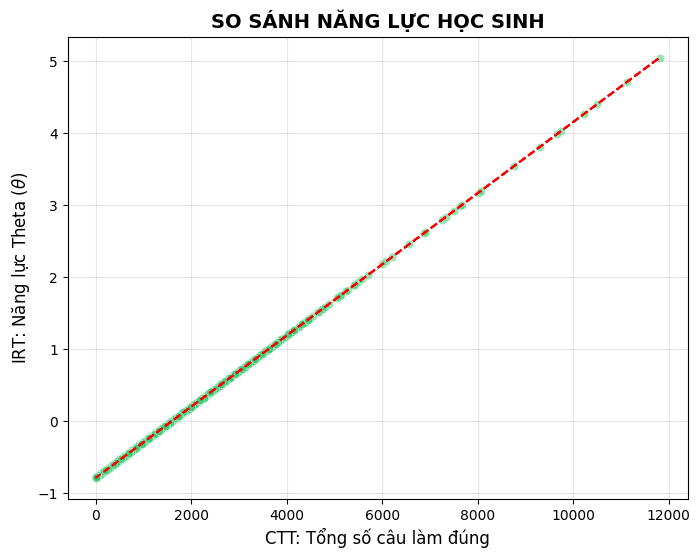

In [17]:
# Cell 6
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ghép dữ liệu Năng lực từ CTT và IRT
df_student_compare = student.merge(student_irt, on='user_id', how='inner')

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_student_compare, 
    x='ability_total_score', 
    y='ability_theta', 
    alpha=0.5, 
    color='#2ecc71'
)

# Vẽ đường xu hướng
df_stu_clean = df_student_compare.dropna(subset=['ability_total_score', 'ability_theta'])
m1, b1 = np.polyfit(df_stu_clean['ability_total_score'], df_stu_clean['ability_theta'], 1)
plt.plot(df_stu_clean['ability_total_score'], m1*df_stu_clean['ability_total_score'] + b1, color='red', linestyle='--')

plt.title('SO SÁNH NĂNG LỰC HỌC SINH', fontsize=14, fontweight='bold')
plt.xlabel('CTT: Tổng số câu làm đúng', fontsize=12)
plt.ylabel('IRT: Năng lực Theta ($\\theta$)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

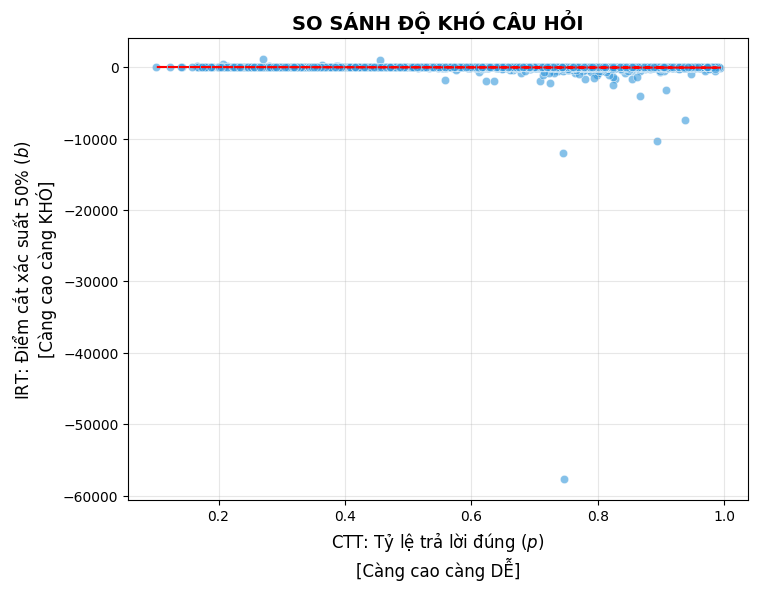

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_compare, 
    x='CTT_Difficulty_p', 
    y='IRT_Difficulty_b', 
    alpha=0.6, 
    color='#3498db'
)

# Vẽ đường xu hướng
df_diff_clean = df_compare.dropna(subset=['CTT_Difficulty_p', 'IRT_Difficulty_b'])
m2, b2 = np.polyfit(df_diff_clean['CTT_Difficulty_p'], df_diff_clean['IRT_Difficulty_b'], 1)
plt.plot(df_diff_clean['CTT_Difficulty_p'], m2*df_diff_clean['CTT_Difficulty_p'] + b2, color='red', linestyle='--')

plt.title('SO SÁNH ĐỘ KHÓ CÂU HỎI', fontsize=14, fontweight='bold')
plt.xlabel('CTT: Tỷ lệ trả lời đúng ($p$) \n[Càng cao càng DỄ]', fontsize=12)
plt.ylabel('IRT: Điểm cắt xác suất 50% ($b$) \n[Càng cao càng KHÓ]', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

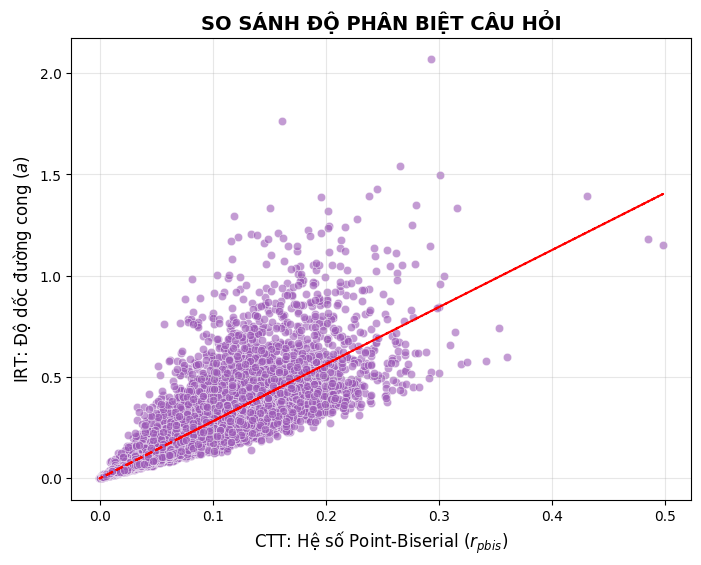

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_compare, 
    x='CTT_Discrimination_pbis', 
    y='IRT_Discrimination_a', 
    alpha=0.6, 
    color='#9b59b6'
)

# Vẽ đường xu hướng
df_disc_clean = df_compare.dropna(subset=['CTT_Discrimination_pbis', 'IRT_Discrimination_a'])
m3, b3 = np.polyfit(df_disc_clean['CTT_Discrimination_pbis'], df_disc_clean['IRT_Discrimination_a'], 1)
plt.plot(df_disc_clean['CTT_Discrimination_pbis'], m3*df_disc_clean['CTT_Discrimination_pbis'] + b3, color='red', linestyle='--')

plt.title('SO SÁNH ĐỘ PHÂN BIỆT CÂU HỎI', fontsize=14, fontweight='bold')
plt.xlabel('CTT: Hệ số Point-Biserial ($r_{pbis}$)', fontsize=12)
plt.ylabel('IRT: Độ dốc đường cong ($a$)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()